Simplified Attention Mechanism: Focuses on contextual mapping and excludes any weights or bias

In [66]:
import torch

In [67]:
inputs = torch.rand(6,3)

print(inputs)

print("Your journey starts with one step")

tensor([[0.4713, 0.5140, 0.3051],
        [0.9693, 0.9776, 0.9719],
        [0.7534, 0.2093, 0.4684],
        [0.4337, 0.5077, 0.3785],
        [0.0240, 0.7270, 0.6711],
        [0.0288, 0.3417, 0.3371]])
Your journey starts with one step


Visualize the tensors (makeshift vector embeddings)

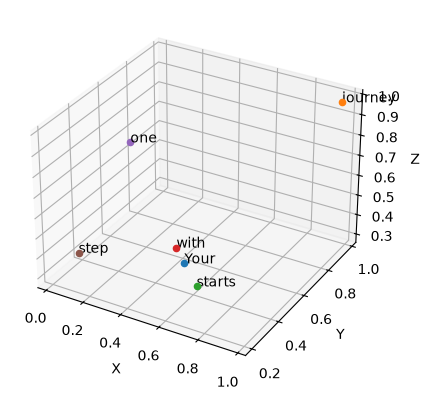

In [68]:
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D

import numpy

words = ["Your", "journey", "starts", "with", "one", "step"]

x_crd = inputs[:, 0].numpy()
y_crd = inputs[:, 1].numpy()
z_crd = inputs[:, 2].numpy()

fig = plt.figure()

ax = fig.add_subplot(111, projection='3d')

for x , y, z , word in zip(x_crd,y_crd, z_crd, words):
    ax.scatter(x,y,z)
    ax.text(x,y,z,word, fontsize=10)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.show()

*NOTE: The embeddings were created at random, so the visualization above is not accurate. In practice, dimensions are far beyond 3d, however the concept is similar. Words can be closer or farther from each other depending on how similar they are (effective and trained vector embeddings)

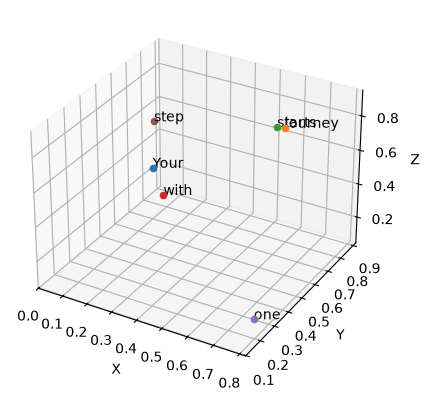

In [69]:
words = ["Your", "journey", "starts", "with", "one", "step"]

inputs_posttrained = torch.tensor([ [0.44, 0.15, 0.89], #Your
                                    [0.55, 0.87, 0.66], #journey
                                    [0.53, 0.85, 0.67], #starts
                                    [0.22, 0.58, 0.33], #with
                                    [0.77, 0.25, 0.10], #one
                                    [0.05, 0.80, 0.55]])  #step
                                    
x_crd = inputs_posttrained[:, 0].numpy()
y_crd = inputs_posttrained[:, 1].numpy()
z_crd = inputs_posttrained[:, 2].numpy()

fig = plt.figure()

ax = fig.add_subplot(111, projection='3d')

for x , y, z , word in zip(x_crd,y_crd, z_crd, words):
    ax.scatter(x,y,z)
    ax.text(x,y,z,word, fontsize=10)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.show()

A better trained embedding such as the one above (vectors are arbitrarily defined, assume that after multiple training iterations it reaches these values). In this 3D space, we can see that there is a similarity between words like journey and start, while the other words are distanced from each other showing no relation

In [70]:
#example: attention score calculation for the word journey
query = inputs_posttrained[1]

#empty tensor to store attention scores
attention_score_2 = torch.empty(inputs_posttrained .shape[0])

#compute attention scores for each word
for i,x_i in enumerate(inputs_posttrained ):
    #attention score is the dot product of the query and the input vector. DP is used for measuring alignement of vecotrs (in this case cosine similarity)
    attention_score_2[i] = torch.dot(x_i, query)

print("Attention score for journey:", attention_score_2)

Attention score for journey: tensor([0.9599, 1.4950, 1.4732, 0.8434, 0.7070, 1.0865])


*NOTE: attention score of the query word is the highest because it is the word being used (highest dot product by default). We see that "starts" has the second highest value which corresponds to the visualization in the graph above and the word "one" has the lowest value

Now, we need interpretability. We normalize the attention scores 

In [71]:
attention_weights_2 = attention_score_2 / attention_score_2.sum()

print("Normalized attention scores (attention weights):", attention_weights_2)

print("Sum:", attention_weights_2.sum())

Normalized attention scores (attention weights): tensor([0.1462, 0.2277, 0.2244, 0.1285, 0.1077, 0.1655])
Sum: tensor(1.)


Scores and weights are intuitivley the same, the only difference is that weights are normalized so the sum is 1

In [72]:
def naive_softmax(x):
    return torch.exp(x)/torch.exp(x).sum()

attn_weight_2_naive = naive_softmax(attention_score_2)

print(attn_weight_2_naive)

print(attn_weight_2_naive.sum())

tensor([0.1393, 0.2378, 0.2327, 0.1240, 0.1082, 0.1581])
tensor(1.)


In [73]:
context_vector = torch.zeros(query.shape)
for i,x_i in enumerate(inputs_posttrained):
    context_vector += attention_weights_2[i] * x_i

print(context_vector)

tensor([0.4280, 0.6446, 0.5750])


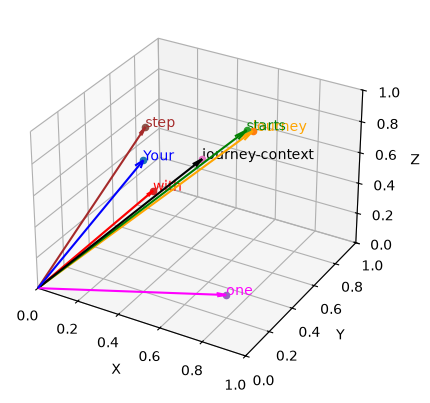

In [74]:
inputs_posttrained2 = torch.tensor([ [0.44, 0.15, 0.89], #Your
                                    [0.55, 0.87, 0.66], #journey
                                    [0.53, 0.85, 0.67], #starts
                                    [0.22, 0.58, 0.33], #with
                                    [0.77, 0.25, 0.10], #one
                                    [0.05, 0.80, 0.55], #step
                                    [0.4280, 0.6446, 0.5750]]) # <- context vector

x_crd = inputs_posttrained2[:, 0].numpy()
y_crd = inputs_posttrained2[:, 1].numpy()
z_crd = inputs_posttrained2[:, 2].numpy()

words = ["Your", "journey", "starts", "with", "one", "step", "journey-context"]

colors = ['b', 'orange', 'g', 'r', 'magenta', 'brown', 'black']

fig = plt.figure()

ax = fig.add_subplot(111, projection='3d')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

for x, y, z in zip(x_crd, y_crd, z_crd):
    ax.scatter(x, y, z)

for (x, y, z, word, color) in zip(x_crd, y_crd, z_crd, words, colors):
    ax.quiver(0, 0, 0, x, y, z, color=color, arrow_length_ratio=0.05)
    ax.text(x, y, z, word, fontsize=10, color=color)

ax.set_xlim([0,1])
ax.set_ylim([0,1])
ax.set_zlim([0,1])


plt.show()

Expand beyond just the word "journey"

In [75]:
attention_scores = torch.empty(6,6)

for i, x_i in enumerate(inputs_posttrained):

    for j, x_j in enumerate(inputs_posttrained):

        attention_scores[i , j] = torch.dot(x_i, x_j)

print(attention_scores)

tensor([[1.0082, 0.9599, 0.9570, 0.4775, 0.4653, 0.6315],
        [0.9599, 1.4950, 1.4732, 0.8434, 0.7070, 1.0865],
        [0.9570, 1.4732, 1.4523, 0.8307, 0.6876, 1.0750],
        [0.4775, 0.8434, 0.8307, 0.4937, 0.3474, 0.6565],
        [0.4653, 0.7070, 0.6876, 0.3474, 0.6654, 0.2935],
        [0.6315, 1.0865, 1.0750, 0.6565, 0.2935, 0.9450]])


In [76]:
attention_scores = inputs_posttrained @ inputs_posttrained.T
print(attention_scores)

tensor([[1.0082, 0.9599, 0.9570, 0.4775, 0.4653, 0.6315],
        [0.9599, 1.4950, 1.4732, 0.8434, 0.7070, 1.0865],
        [0.9570, 1.4732, 1.4523, 0.8307, 0.6876, 1.0750],
        [0.4775, 0.8434, 0.8307, 0.4937, 0.3474, 0.6565],
        [0.4653, 0.7070, 0.6876, 0.3474, 0.6654, 0.2935],
        [0.6315, 1.0865, 1.0750, 0.6565, 0.2935, 0.9450]])


In [ ]:
#we are instructing softmax func to apply softmax to last dimension of vector
attn_weights = torch.softmax(attention_scores, dim = -1)

print(attn_weights)

tensor([[0.2102, 0.2002, 0.1997, 0.1236, 0.1221, 0.1442],
        [0.1393, 0.2378, 0.2327, 0.1240, 0.1082, 0.1581],
        [0.1411, 0.2364, 0.2315, 0.1244, 0.1078, 0.1588],
        [0.1438, 0.2073, 0.2047, 0.1461, 0.1262, 0.1719],
        [0.1544, 0.1967, 0.1929, 0.1373, 0.1887, 0.1301],
        [0.1381, 0.2177, 0.2152, 0.1416, 0.0985, 0.1890]])


In [82]:
contxt_vctrs = attn_weights @ inputs_posttrained

print(contxt_vctrs)

tensor([[0.4369, 0.5930, 0.5853],
        [0.4339, 0.6510, 0.5755],
        [0.4331, 0.6498, 0.5759],
        [0.4237, 0.6297, 0.5573],
        [0.4603, 0.5891, 0.5322],
        [0.4110, 0.6509, 0.5712]])
